# Explore here

In [10]:
# Librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Data 

df = pd.read_csv('../data/raw/Lake_Bilancino.csv')
df

,Date,Rainfall_S_Piero,Rainfall_Mangona,Rainfall_S_Agata,Rainfall_Cavallina,Rainfall_Le_Croci,Temperature_Le_Croci,Lake_Level,Flow_Rate
0,03/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
1,04/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
2,05/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
3,06/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
4,07/06/2002,NaN,NaN,NaN,NaN,NaN,NaN,249.44,0.31
...,...,...,...,...,...,...,...,...,...
6598,26/06/2020,0.0,0.0,0.0,0.0,0.0,22.50,250.85,0.60
6599,27/06/2020,0.0,0.0,0.0,0.0,0.0,23.40,250.84,0.60
6600,28/06/2020,0.0,0.0,0.0,0.0,0.0,21.50,250.83,0.60
6601,29/06/2020,0.0,0.0,0.0,0.0,0.0,23.20,250.82,0.60


In [12]:
# Aislamos los datos pertinentes al problema

df2 =df[['Date','Lake_Level']]
df2

,Date,Lake_Level
0,03/06/2002,249.43
1,04/06/2002,249.43
2,05/06/2002,249.43
3,06/06/2002,249.43
4,07/06/2002,249.44
...,...,...
6598,26/06/2020,250.85
6599,27/06/2020,250.84
6600,28/06/2020,250.83
6601,29/06/2020,250.82


In [13]:
# Transformamos la columana de fecha en el index

df2.index = df2['Date']
df2.drop('Date',axis=1,inplace=True)
df2

/var/folders/3p/lzyp6b9542b_8mk_q04l5p100000gn/T/ipykernel_10148/4098007734.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop('Date',axis=1,inplace=True)


,Lake_Level
Date,
03/06/2002,249.43
04/06/2002,249.43
05/06/2002,249.43
06/06/2002,249.43
07/06/2002,249.44
...,...
26/06/2020,250.85
27/06/2020,250.84
28/06/2020,250.83


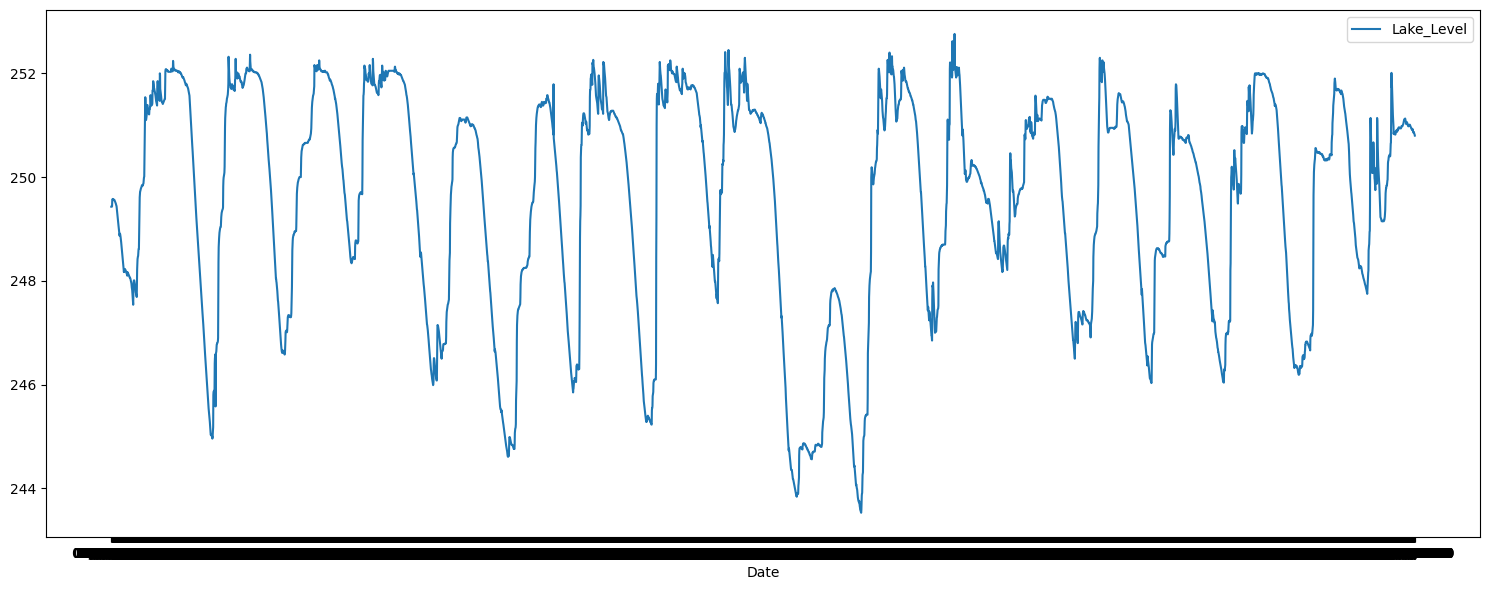

In [22]:
# Visualización Serie Temporal

fig, axis = plt.subplots(figsize = (15, 6))

sns.lineplot(data = df2)

plt.tight_layout()

plt.show()


In [24]:
# Descomposición de la serie

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df2, period = 365)
decomposition

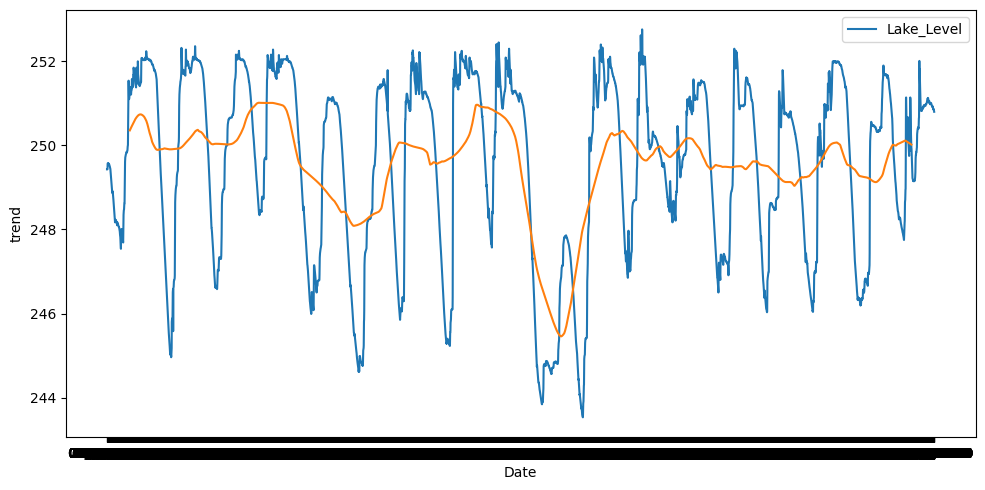

In [ ]:
# Análisis de tendencia

tendencia = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df2)
sns.lineplot(data = tendencia)

plt.tight_layout()

plt.show()

Se observa estabilidad en el nivel del lago, con su períodos comunes de sequía más o menos graves.

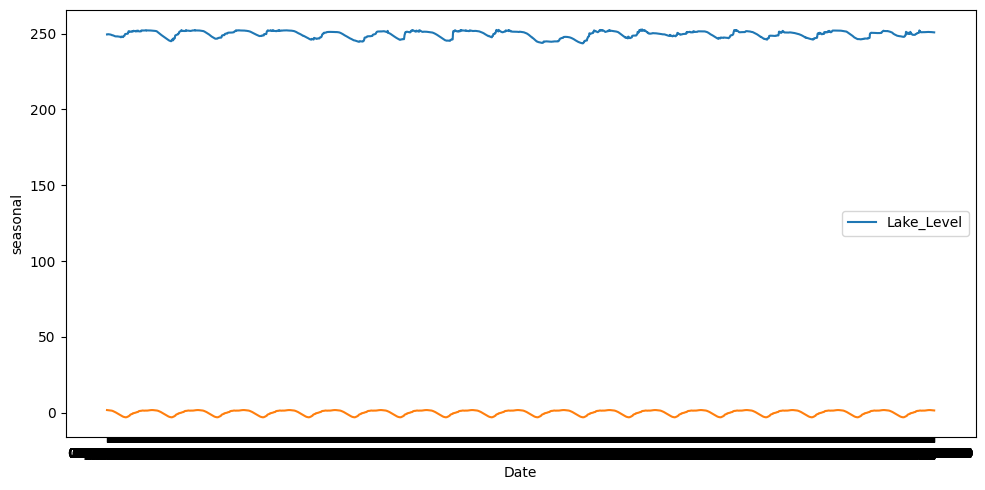

In [26]:
# Análisis de estacionalidad

seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df2)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

Se observa una alta estacionalidad en el nivel del lago, correlacionado a las estaciones del año.

In [28]:
# Evaluación de estacionalidad (Dickey-Fuller Test)

from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(df2)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -6.880991e+00
p-value                        1.433634e-09
#Lags Used                     3.500000e+01
Number of Observations Used    6.567000e+03
Critical Value (1%)           -3.431346e+00
Critical Value (5%)           -2.861980e+00
Critical Value (10%)          -2.567004e+00
dtype: float64

p-values es muy bajo, por lo que la serie es estacionaria

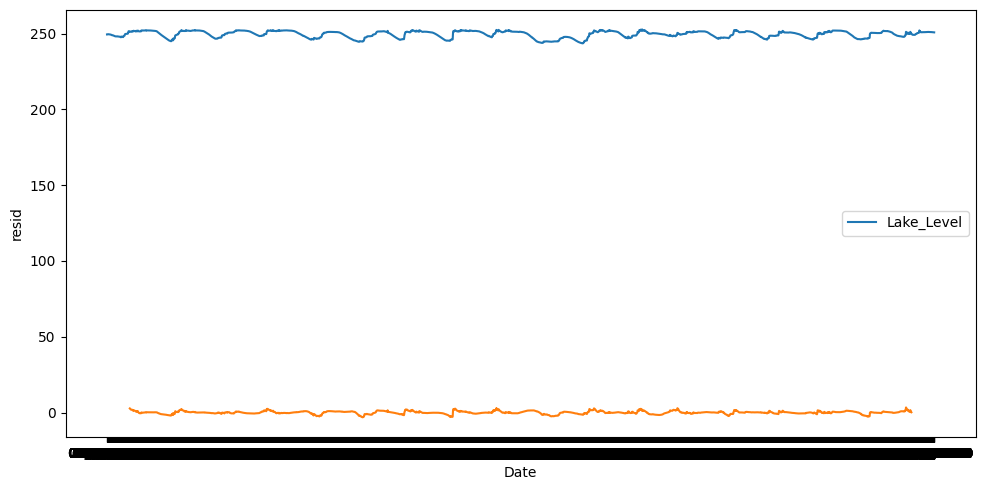

In [29]:
# Análisis de variabilidad (Residuos)

residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df2)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

Residuos muy pequeños, no son relevantes para la predicción

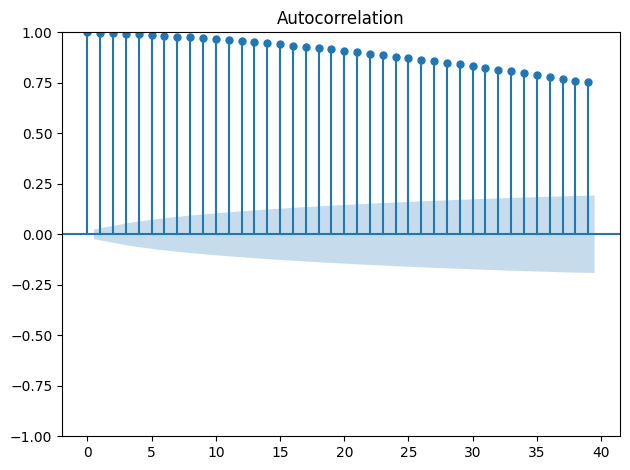

In [30]:
# Análisis de autocorrelación

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df2)

plt.tight_layout()

plt.show()

Los componenetes de la serie son autorregresivos (altamente correlacionados), lo que sigue la lógica de las conclusiones anteriores.

In [32]:
from pmdarima import auto_arima

model = auto_arima(df2, seasonal = True, trace = True, )

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject